# General phase-matching pipeline

Repeatable version of the ad-hoc `PhaseMatching_Table.ipynb` investigation, built around one
lesson learned the hard way there: **raw mode index is not a stable identifier across geometry or
wavelength** (a mode's index has been observed to swing by 7+ just from a 50nm width change, and a
single mislabeled mode -- TM13 mistaken for TM40 -- cost an entire session of debugging). So the
workflow here puts ALL human visual confirmation up front, at one anchor geometry, and everything
after that runs unattended (potentially for hours) using overlap-based tracking that walks between
neighboring grid points rather than jumping straight from the anchor to every target.

**Workflow:**
1. Set the anchor geometry and materials.
2. Visually survey modes at the anchor (`visual_mode_survey`) -- review the plots, then fill in
   `modes_of_interest` with the confirmed index for each named mode.
3. (Optional) Auto-scan for *other* modes' crossings at the anchor (`scan_for_crossings`) -- surfaces
   candidates like TM02/TM20 without needing to know their index ahead of time. Visually confirm any
   candidates you want to add before including them in step 4.
4. Define the target geometry grid to cover.
5. Long automated run: for each named mode, walk its mode index across the whole grid
   (`walk_mode_across_points`), then compute the phase-matching crossing wavelength and
   width/height gradients at every grid point (`phase_matching_row`).
6. Assemble results into a table and save to CSV.

In [3]:
# [cell1] Config: RUN_TAG/RUN_DIR, anchor geometry, ellipsometry equation
import numpy as np
import itertools
import os
import emode_helpers as eh

# --- Run identity: keeps this dataset's checkpoint/CSVs/field_plots isolated from any other
# ellipsometry dataset run through this same notebook (Steps 4-9 all derive their paths from
# RUN_DIR). Change RUN_TAG before starting a new dataset -- do NOT reuse a tag once a run under it
# has started, or its checkpoint/CSVs will silently mix two different ellipsometry fits together.
RUN_TAG = 'ALN_avgLibrary82026'
RUN_DIR = os.path.abspath(os.path.join('runs', RUN_TAG))
os.makedirs(RUN_DIR, exist_ok=True)

# --- Anchor geometry + materials (edit for your design) ---
h_anchor = 350.0  # [nm]
w_anchor = 550.0  # [nm]
dx, dy = 10.0, 10.0

# Fit to Average of all Ellipsometry Data.
# Previous dataset (ALN_am135comsol) archived to runs/ALN_am135comsol/ -- see
# runs/ALN_am135comsol/run_info.md for its exact eq_o/eq_e and full git history for this cell.
eq_o = '(1+0.511749/(1+0.132923/x**2)+2.79492/(1-0.0235549/x**2)+204361000000/(1-1301930000000/x**2))**0.5'
eq_e = '(1-0.000113071/(1-0.0460142/x**2)+3.39797/(1-0.0197552/x**2)-93982100/(1+818169000/x**2))**0.5'

anisotropic_equation = f"[{eq_o},{eq_e},{eq_o}]"


### Sanity check: geometry and material dispersion

Two quick visual checks before doing any real solving -- confirm the waveguide cross-section looks
right, and confirm the ellipsometry-fit dispersion equations (`eq_o`/`eq_e`) look physically
reasonable over the wavelength range this pipeline actually uses (~UV signal to visible/near-IR
pump).

In [2]:
# [geom_check_1] Sanity check: solve once and plot the geometry cross-section
# Geometry check: solves once (cheap, num_modes=2) just to populate a profile, then plots the
# shape outlines and the resulting index cross-section -- confirms core/substrate/topclad
# dimensions and materials look right before any real (expensive) solving happens.
geometry_check_wavelength = 230.0  # [nm] -- representative value, doesn't need to be exact

em = eh.launch_session('geometry_check', verbose=False)
try:
    eh.setup_waveguide(em, anisotropic_equation, h_anchor, w_anchor)
    eh.solve_modes(em, 'geom_check', wavelength=geometry_check_wavelength, num_modes=2,
                   x_resolution=dx, y_resolution=dy, max_effective_index=2.6)
    em.plot(component='Shapes')
    em.plot(component='Index')
finally:
    em.close(save=False)

<string>:1: RuntimeWarning: invalid value encountered in sqrt


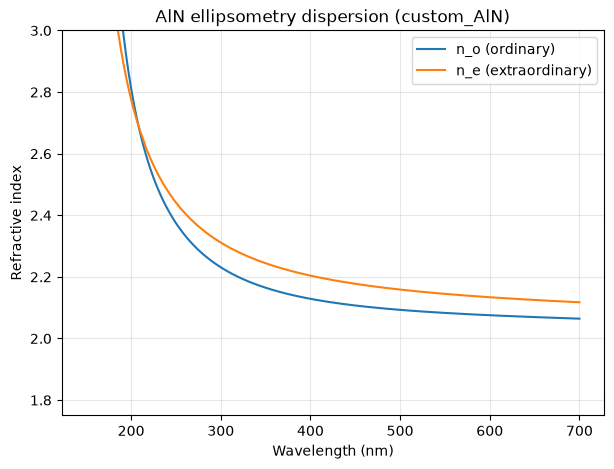

In [4]:
# [geom_check_2] Sanity check: evaluate eq_o/eq_e directly (no EMode)
# Ellipsometry check: evaluate eq_o/eq_e directly (same strings passed to add_material) over the
# wavelength range this pipeline spans -- roughly the UV SHG signal (~150-300nm) through the
# visible/near-IR pump (2x that, up to ~700nm+).
import matplotlib.pyplot as plt

wl_um = np.linspace(0.15, 0.7, 200)  # [um] -- eq_o/eq_e expect x in um (add_material's wavelength_unit)
x = wl_um
n_o = eval(eq_o)
n_e = eval(eq_e)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(wl_um * 1000, n_o, label='n_o (ordinary)')
ax.plot(wl_um * 1000, n_e, label='n_e (extraordinary)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Refractive index')
ax.set_title('AlN ellipsometry dispersion (custom_AlN)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(1.75, 3)
plt.show()

## Step 1: visual mode survey at the anchor

Solves once at the anchor and plots each mode in `modes_to_plot` for you to review. Adjust the
range/wavelength below to cover whatever modes you're interested in -- widen it if the mode you
want isn't in the initial range. This is the ONLY step that needs your eyes on a plot; everything
after this cell is unattended.

In [ ]:
# [cell3] Step 1: visual mode survey at the anchor
survey_wavelength = 230.0  # [nm] -- pick something in the general region of interest
modes_to_plot = range(18, 35)  # narrowed for smoke test -- widen to range(0, 40) for a real new geometry
modes_to_plot = [23,30]
survey_wavelength = 227.0  # [nm] -- pick something in the general region of interest
modes_to_plot = [13,42]
modes_to_plot = [19,44]
fdm_survey = eh.visual_mode_survey(anisotropic_equation, h_anchor, w_anchor, survey_wavelength,
                                    num_modes=45, modes_to_plot=modes_to_plot,
                                    x_resolution=dx, y_resolution=dy)

=== Survey at h=350.0, w=550.0, wavelength=227.0 (all plots below are this SAME geometry, only mode index varies) ===
-- mode 13 --  n_eff=2.39071
-- mode 42 --  n_eff=2.08451


## Step 1b: record confirmed mode indices

After reviewing the plots above, fill in the confirmed index for each named mode of interest.
`wavelengths_shg` should be wide enough to contain that mode's crossing across the ENTIRE target
grid you plan to sweep in step 4 -- not just at the anchor. A mode with a large `dWL/dwidth` (like
TM40, ~0.24 nm/nm) can shift its crossing wavelength by tens of nm across a wide grid, so give it a
generous window; a less width-sensitive mode (like TM04, ~-0.012 nm/nm) can use a narrower one.

`num_modes`/`window` for the walk should have headroom above the anchor index, since index has
been observed to shift by 7+ over a single 50nm step -- err generous, the walk is cheap per step.

In [ ]:
# [cell5] Step 1b: modes_of_interest
modes_of_interest = {
    'TM04': dict(anchor_mode_idx=44, num_modes=100, window=25, overlap_threshold=0.95,
                 review_threshold=0.75, max_jump_distance=30.0,
                 wavelengths_shg=np.arange(200, 300, 2.0), tracking_wavelength=227),
    'TM40': dict(anchor_point=(350.0, 400.0), anchor_mode_idx=25, num_modes=50, window=25,
                 overlap_threshold=0.95, review_threshold=0.75, max_jump_distance=30.0,
                 wavelengths_shg=np.arange(200, 320, 2.0), tracking_wavelength=242),
}
# anchor_mode_idx values above are carried over from ALN_am135comsol as a starting guess only --
# a different ellipsometry fit can shift which raw index the anchor mode lands at, just like a
# geometry/wavelength/num_modes change can (see the Mode Tracking Manual, Part I). Reconfirm both
# via Step 1 / the manual anchor recheck cells below BEFORE trusting Step 4 for this dataset.
#
# overlap_threshold: a walk step at/above this is accepted cleanly.
#
# review_threshold: a walk step below overlap_threshold but at/above this is FLAGGED rather than
# rejected -- still usable as a source for tracking later points (so one shaky-but-plausible match
# doesn't force its neighbors onto a much longer, less reliable jump), but marked for manual review
# via field_plots/ once Step 5 has run. Below review_threshold, a step is REJECTED outright
# (excluded from Step 5, retried automatically on a later run).
#
# max_jump_distance (nm): a walk step is only attempted if a solved point exists within this
# distance of the target -- otherwise the point is left unattempted this run (not guessed at from a
# much farther point) and retried later, once a nearer neighbor has hopefully succeeded.
#
# ALN_avgLibrary82026 (2026-08-25): both modes now use a 25nm width-grid step (Step 3) -- TM04
# widened from its earlier 12.5nm step to speed up an unattended 1-2 day run, matching TM40's grid
# density. max_jump_distance=30.0 for both, sized for a 25nm width step + 15nm height step diagonal
# (~29.2nm); 20.0 (TM04's old value, sized for its old 12.5nm step) would be too strict here -- a
# single same-row 25nm step would already exceed it, which is exactly what stalled TM40 the first
# time this mismatch happened (see ALN_am135comsol's history in git).
#
# num_modes: TM04 lowered to 100 (from ALN_am135comsol's 130) after confirming anchor_mode_idx=44
# holds at both -- still generous headroom above it. TM40 num_modes=50 unchanged. Watch for
# `saturated` warnings during the walk and raise num_modes if they show up.
#
# window=25: candidates checked per walk step for overlap tracking. Kept moderate rather than a
# "hammer search" -- large batches of overlap() calls have been observed to crash EMode.exe on
# this machine (see track_mode's docstring).
#
# TM40 anchor_point=(350, 400) instead of the shared (h_anchor, w_anchor) -- carried over from
# ALN_am135comsol's cleanup, still within this dataset's narrower 300-450nm TM40 range.


### Manual anchor recheck at the new anchor point

Opens the interactive EMode Plot GUI so you can flip through mode numbers directly within one
window, rather than looping through a fixed list. Blocks here until you close that window --
update `anchor_mode_idx` above once you've confirmed the right mode number, then re-run cell 5.

In [ ]:
# [5fba790e] Manual anchor recheck -- TM04
_recheck_em = eh.launch_session('anchor_recheck', verbose=False)
try:
    eh.setup_waveguide(_recheck_em, anisotropic_equation, h_anchor, w_anchor)
    eh.solve_modes(_recheck_em, 'recheck', wavelength=modes_of_interest['TM04']['tracking_wavelength'],
                    num_modes=modes_of_interest['TM04']['num_modes'],
                    x_resolution=dx, y_resolution=dy, max_effective_index=2.6)
    _recheck_em.plot(component='Ey')  # interactive -- change mode number within this window
finally:
    _recheck_em.close(save=False)

### Manual anchor recheck for TM40's cleanup anchor (350, 400)

Same purpose as the cell above, but for TM40's `anchor_point` -- this one was inferred from
gradient smoothness alone (not yet visually confirmed), unlike TM04's anchor which was confirmed
via `visual_mode_survey` earlier. Blocks until you close the window; update `anchor_mode_idx` in
TM40's config above if 23 turns out to be wrong.

In [ ]:
# [95f102f9] Manual anchor recheck -- TM40
_tm40_anchor_h, _tm40_anchor_w = modes_of_interest['TM40']['anchor_point']
_recheck_em = eh.launch_session('anchor_recheck_tm40', verbose=False)
try:
    eh.setup_waveguide(_recheck_em, anisotropic_equation, _tm40_anchor_h, _tm40_anchor_w)
    eh.solve_modes(_recheck_em, 'recheck', wavelength=modes_of_interest['TM40']['tracking_wavelength'],
                    num_modes=modes_of_interest['TM40']['num_modes'],
                    x_resolution=dx, y_resolution=dy, max_effective_index=2.6)
    _recheck_em.plot(component='Ey')  # interactive -- change mode number within this window
finally:
    _recheck_em.close(save=False)

## Step 2 (optional): auto-scan for other modes' crossings at the anchor

Looks for a phase-matching crossing across EVERY raw mode index at the anchor point, in exactly 2
EMode sweep calls (not one per index). This surfaces *candidates* like TM02/TM20 -- it does NOT
identify them by name. Visually confirm any index you want to keep (via `visual_mode_survey` with
`modes_to_plot=[that index]`) before adding it to `modes_of_interest` above and re-running from
Step 1b.

In [ ]:
# [cell7] Step 2 (optional): scan for other modes' crossings
scan_wavelengths = np.arange(160, 340, 2.0)
already_named = {cfg['anchor_mode_idx'] for cfg in modes_of_interest.values()}

candidates = eh.scan_for_crossings(anisotropic_equation, h_anchor, w_anchor, scan_wavelengths,
                                    fund_mode_idx=0, num_modes_fund=2, num_modes_scan=45,
                                    exclude_indices=already_named | {0},
                                    x_resolution=dx, y_resolution=dy)

print(f"Found {len(candidates)} candidate mode(s) with a crossing in "
      f"{scan_wavelengths[0]:.0f}-{scan_wavelengths[-1]:.0f}nm (excluding already-named modes):")
for mode_idx, info in sorted(candidates.items()):
    print(f"  mode {mode_idx}: crossing={info['wavelength_shg']:.3f}nm, n_eff={info['n_eff']:.5f}")

## Step 3: define the target geometry grid

Edit `h_values`/`w_values` to whatever range you want covered. The walk in Step 4 handles an
arbitrary set of (h, w) points, not just a rectangular grid, if you'd rather build `target_points`
some other way.

In [ ]:
# [cell9] Step 3: target geometry grid
# ALN_avgLibrary82026 (2026-08-25): both modes swept at a 25nm width step -- TM04 widened from its
# earlier 12.5nm step (see ALN_am135comsol's history) to roughly halve the point count and fit an
# unattended 1-2 day run, at the cost of the extra tracking margin the finer step bought. Paired
# with max_jump_distance=30.0 for both modes (Step 1b).
h_values = [335.0, 350.0, 365.0]
w_values_tm04 = [300.0 + 25.0 * i for i in range(19)]  # 300.0 .. 750.0 in 25nm steps

# TM40 scoped to a narrower width range than ALN_am135comsol's (300-750nm) -- 300-450nm covers the
# range of interest for this dataset without paying for the wider sweep. Anchored at
# tm40_anchor_point below rather than the global (h_anchor, w_anchor), same as ALN_am135comsol.
w_values_tm40 = [300.0 + 25.0 * i for i in range(7)]  # 300.0 .. 450.0 in 25nm steps
tm40_anchor_point = (350.0, 400.0)

target_points = {
    'TM04': [(h, w) for h, w in itertools.product(h_values, w_values_tm04) if (h, w) != (h_anchor, w_anchor)],
    'TM40': [(h, w) for h, w in itertools.product(h_values, w_values_tm40) if (h, w) != tm40_anchor_point],
}
for _mode_name, _pts in target_points.items():
    print(f"{_mode_name}: {len(_pts)} target points queued.")


## Step 4: long run -- walk mode index across the grid, for each named mode

This is the unattended, potentially-hours-long part. Resilient to individual point failures (a
failed point doesn't stop the rest); progress prints as it goes so you can check in without
watching continuously.

In [ ]:
# [cell11] Step 4: walk mode index across the grid
import json
import os
import time

# Toggle: save a field plot immediately for every walk step -- accepted, flagged, AND rejected --
# rather than waiting for Step 5 (which only starts once the whole walk finishes, and never covers
# rejected points at all). Lets you monitor mode shape/identity, including WHY a point was
# rejected, during a long unattended run. Costs one extra EMode solve+plot per step (roughly
# doubles Step 4's per-point time). Turn off to run Step 4 at its original pace.
SAVE_WALK_PROGRESS_PLOTS = True

walk_checkpoint_path = os.path.join(RUN_DIR, 'walked_indices_checkpoint.json')
walked_indices = {}  # mode_name -> {point: {'mode_idx', 'overlap', ...} or None}
field_plots_dir = os.path.join(RUN_DIR, 'field_plots')
os.makedirs(field_plots_dir, exist_ok=True)
_timing = {'last': time.time()}  # wall-clock time of the previous point, for the per-point elapsed print

# Heartbeat: one line appended after every point, so "is this hung?" is a one-second read of this
# file's last-modified time / last line instead of guessing from EMode.exe's CPU usage in Task
# Manager -- useful across a long unattended run where you're mainly checking it isn't stuck.
_progress_log_path = os.path.join(RUN_DIR, 'progress.log')


def _serialize_walked(walked):
    """JSON-safe copy of walked_indices (tuple points/tracked_from -> lists)."""
    out = {}
    for mode_name, points in walked.items():
        out[mode_name] = {}
        for (h, w), info in points.items():
            if info is None:
                out[mode_name][f"{h},{w}"] = None
            else:
                info = dict(info)
                if info.get('tracked_from') is not None:
                    info['tracked_from'] = list(info['tracked_from'])
                out[mode_name][f"{h},{w}"] = info
    return out


def _deserialize_walked(raw):
    """Inverse of _serialize_walked: string point keys -> (h, w) tuples, tracked_from lists -> tuples."""
    walked = {}
    for mode_name, points in raw.items():
        walked[mode_name] = {}
        for key, info in points.items():
            h_str, w_str = key.split(',')
            point = (float(h_str), float(w_str))
            if info is not None:
                info = dict(info)
                if info.get('tracked_from') is not None:
                    info['tracked_from'] = tuple(info['tracked_from'])
            walked[mode_name][point] = info
    return walked


def _save_walk_plot(mode_name, h, w, mode_idx, wavelength, num_modes, tag_suffix='walkcheck'):
    """Immediate field plot at the tracking wavelength (not the true phase-matching crossing
    wavelength -- that isn't known until Step 5's find_crossing runs), saved right after Step 4
    resolves a point so you can monitor mode shape/identity while the walk is still running.
    `tag_suffix` distinguishes an accepted/flagged mode ('walkcheck') from a rejected candidate
    ('walkcheck_REJECTED') so the two are never confused in field_plots/. Skips points that already
    have one on disk, so re-running/resuming doesn't regenerate them.

    `num_modes` is the CALLER's mode config value (the same num_modes the walk itself used to
    verify this mode_idx) -- NOT mode_idx+10. Re-solving with a smaller num_modes than the walk
    used risks landing on a different physical mode at the same index (mode index isn't stable
    across a num_modes change any more than across geometry/wavelength -- see CLAUDE.md), which is
    exactly what corrupted a large fraction of TM40's Step 5 results on 2026-08-24.
    """
    tag = f"{mode_name}_h{h:.1f}_w{w:.1f}_mode{mode_idx}_{tag_suffix}"
    path = os.path.join(field_plots_dir, tag)
    if not os.path.exists(path + '.png'):
        eh.save_mode_plot(anisotropic_equation, h, w, wavelength, mode_idx,
                           num_modes=num_modes, x_resolution=dx, y_resolution=dy,
                           file_name=path)


if os.path.exists(walk_checkpoint_path):
    with open(walk_checkpoint_path) as f:
        walked_indices = _deserialize_walked(json.load(f))
    print(f"Resuming from {walk_checkpoint_path}: "
          f"{ {m: len(p) for m, p in walked_indices.items()} } points loaded per mode")

for mode_name, cfg in modes_of_interest.items():
    mode_target_points = target_points[mode_name]
    mode_anchor_point = cfg.get('anchor_point', (h_anchor, w_anchor))

    # only points already SUCCESSFULLY solved (and not saturated) are skipped -- a previously-failed
    # point (None) is retried since the failure may have been transient (e.g. an EMode file-lock
    # error), and a saturated point is retried too since a wider num_modes on this run might resolve it
    already_solved = {p: info for p, info in walked_indices.get(mode_name, {}).items()
                       if info is not None and not info['saturated']}
    remaining_points = [p for p in mode_target_points if p not in already_solved]

    if not remaining_points:
        print(f"\n=== {mode_name}: all {len(mode_target_points)} points already solved, skipping ===")
        continue
    print(f"\n=== Walking {mode_name} across {len(remaining_points)}/{len(mode_target_points)} "
          f"remaining points ===")

    def _checkpoint(point, info, solved, problems, candidate, mode_name=mode_name, cfg=cfg):
        walked_indices[mode_name] = solved
        with open(walk_checkpoint_path, 'w') as f:
            json.dump(_serialize_walked(walked_indices), f, indent=2)
        for reason, detail in problems:
            eh.log_failed_point('walk', mode_name, point[0], point[1], reason=reason, detail=detail,
                                 csv_path=os.path.join(RUN_DIR, 'failed_points.csv'))
        if SAVE_WALK_PROGRESS_PLOTS:
            try:
                if info is not None:
                    _save_walk_plot(mode_name, point[0], point[1], info['mode_idx'],
                                     cfg['tracking_wavelength'], cfg['num_modes'])
                elif candidate is not None:
                    # rejected, but a real solve happened -- save the candidate that got rejected,
                    # tagged distinctly, so it's easy to eyeball whether the rejection looks like a
                    # genuine mode mismatch or a plausible TM04 that just fell short of the floor
                    _save_walk_plot(mode_name, point[0], point[1], candidate['mode_idx'],
                                     cfg['tracking_wavelength'], cfg['num_modes'],
                                     tag_suffix='walkcheck_REJECTED')
            except Exception as e:
                print(f"  WARNING: walk-progress plot failed for {point}: {repr(e)}")
        now = time.time()
        elapsed_min = (now - _timing['last']) / 60
        _timing['last'] = now
        print(f"  [{elapsed_min:.1f} min for this point]")
        outcome = 'accepted' if (info is not None and not info.get('flagged_for_review')) \
            else ('flagged' if info is not None else 'rejected')
        with open(_progress_log_path, 'a') as f:
            f.write(f"{time.strftime('%Y-%m-%d %H:%M:%S')}  {mode_name}  "
                    f"h={point[0]:.1f} w={point[1]:.1f}  {outcome}  ({elapsed_min:.1f} min)\n")

    walked_indices[mode_name] = eh.walk_mode_across_points(
        anisotropic_equation, mode_anchor_point, cfg['anchor_mode_idx'], remaining_points,
        tracking_wavelength=cfg['tracking_wavelength'], num_modes=cfg['num_modes'],
        window=cfg['window'], overlap_threshold=cfg.get('overlap_threshold', 0.8),
        review_threshold=cfg.get('review_threshold'), max_jump_distance=cfg.get('max_jump_distance'),
        x_resolution=dx, y_resolution=dy, on_point=_checkpoint,
        resume_solved=already_solved)

    flagged_points = sorted(p for p, info in walked_indices[mode_name].items()
                             if info is not None and info.get('flagged_for_review'))
    if flagged_points:
        print(f"\n  {len(flagged_points)} {mode_name} point(s) FLAGGED for review "
              f"(check field_plots/ once Step 5 has run): {flagged_points}")

print(f"\nWalk checkpoint saved to {walk_checkpoint_path}")


### Step 4 (alternate): load the walk checkpoint without walking

Use this INSTEAD of the Step 4 cell above when you just want `walked_indices` populated from
whatever's already in `walked_indices_checkpoint.json` -- e.g. to skip past a hung/very slow retry
of already-rejected points and go straight to Step 5. Does no EMode work at all; points that are
currently rejected stay rejected (excluded from Step 5, same as always) rather than being
reattempted.

In [ ]:
# [cfb5af27] Step 4 (alternate): load checkpoint without walking
import json

walk_checkpoint_path = os.path.join(RUN_DIR, 'walked_indices_checkpoint.json')


def _deserialize_walked(raw):
    """Inverse of _serialize_walked (see Step 4 above): string point keys -> (h, w) tuples,
    tracked_from lists -> tuples."""
    walked = {}
    for mode_name, points in raw.items():
        walked[mode_name] = {}
        for key, info in points.items():
            h_str, w_str = key.split(',')
            point = (float(h_str), float(w_str))
            if info is not None:
                info = dict(info)
                if info.get('tracked_from') is not None:
                    info['tracked_from'] = tuple(info['tracked_from'])
            walked[mode_name][point] = info
    return walked


with open(walk_checkpoint_path) as f:
    walked_indices = _deserialize_walked(json.load(f))

print(f"Loaded {walk_checkpoint_path} directly (no walk attempted): "
      f"{ {m: len(p) for m, p in walked_indices.items()} } points loaded per mode")
for mode_name, points in walked_indices.items():
    solved = sum(1 for info in points.values() if info is not None and not info.get('saturated'))
    rejected = sum(1 for info in points.values() if info is None)
    print(f"  {mode_name}: {solved} solved/flagged, {rejected} still rejected (excluded from Step 5)")


## Step 5: phase-matching crossing + width/height gradient at every point

Uses each point's tracked mode index (from Step 4) directly -- no further tracking uncertainty.
Points where the walk failed or landed on a saturated (num_modes-ceiling) index are skipped with a
printed note rather than silently dropped.

In [ ]:
# [cell13] Step 5: phase-matching crossing + gradients
import csv
import os

partial_csv_path = os.path.join(RUN_DIR, 'general_pipeline_results_partial.csv')
# EMode's em.plot(file_name=...) fails with a relative path that includes a subdirectory (tested:
# a bare relative filename or a fully absolute path both work, but 'subdir/name' does not) -- use
# an absolute path here to sidestep that.
field_plots_dir = os.path.join(RUN_DIR, 'field_plots')
os.makedirs(field_plots_dir, exist_ok=True)

_required_numeric_fields = ('h_core', 'w_core', 'wavelength_shg', 'n_eff', 'dn_dWL_fund', 'dn_dWL_target')
# these six can be blank -- phase_matching_row now returns None for a gradient whose underlying
# perturbation tracked unreliably (see mode_gradient_width_height's overlap_threshold), rather than
# a silently wrong number, and csv.DictWriter round-trips a None as an empty string
_optional_grad_fields = ('dn_dwidth_fund', 'dn_dwidth_target', 'dn_dheight_fund', 'dn_dheight_target',
                          'dWL_dwidth', 'dWL_dheight')


def _float_or_none(value):
    return float(value) if value not in (None, '') else None


all_rows = []
done_keys = set()  # (mode_name, h_core, w_core) already computed and saved -- these are skipped

if os.path.exists(partial_csv_path) and os.path.getsize(partial_csv_path) > 0:
    with open(partial_csv_path, newline='') as f:
        for row in csv.DictReader(f):
            row['target_mode_idx'] = int(row['target_mode_idx'])
            for key in _required_numeric_fields:
                row[key] = float(row[key])
            for key in _optional_grad_fields:
                row[key] = _float_or_none(row[key])
            all_rows.append(row)
            done_keys.add((row['target_mode_name'], row['h_core'], row['w_core']))
    print(f"Resuming from {partial_csv_path}: {len(all_rows)} rows already computed, "
          f"those points will be skipped.")

done_rows_by_key = {(r['target_mode_name'], r['h_core'], r['w_core']): r for r in all_rows}

total_considered = 0
_partial_f = open(partial_csv_path, 'a', newline='')
_partial_writer = csv.DictWriter(_partial_f, fieldnames=list(all_rows[0].keys())) if all_rows else None


def _append_row(row):
    global _partial_writer
    if _partial_writer is None:
        _partial_writer = csv.DictWriter(_partial_f, fieldnames=list(row.keys()))
        _partial_writer.writeheader()
    _partial_writer.writerow(row)
    _partial_f.flush()


def _save_plots(mode_name, h, w, mode_idx, wavelength_shg, num_modes):
    """Save target+fundamental field plots for a matched point, skipping any that already exist on
    disk -- so re-running doesn't regenerate plots for points a previous run already recorded.

    The fundamental plot is always mode TM00 (index 0), but its crossing wavelength (and hence the
    actual field) differs per target mode even at the SAME (h, w) -- e.g. TM04 and TM40 share the
    same anchor geometry but cross the fundamental at different wavelengths. So `mode_name` stays
    in the filename to keep the two distinct, with an explicit '_TM00' suffix so it's clear the
    plotted mode itself is the fundamental, not `mode_name`.

    mode_idx and wavelength_shg are baked into the filename too -- besides being convenient to read
    off directly, this means a result that changes between runs (different tracked mode, different
    phase-matching wavelength) naturally lands in a NEW file instead of silently reusing/skipping a
    stale one that no longer matches the current result for this (h, w).

    `num_modes` (the target mode's plot only -- the fundamental always uses a small fixed value,
    since index 0 is stable regardless of num_modes) is the CALLER's mode config value, matching
    what the walk itself used to verify this mode_idx -- NOT mode_idx+10. See _save_walk_plot's
    docstring in Step 4 for why that distinction matters (it's what corrupted a large fraction of
    TM40's results on 2026-08-24).
    """
    tag = f"{mode_name}_h{h:.1f}_w{w:.1f}_mode{mode_idx}_WL{wavelength_shg:.2f}"
    target_path = os.path.join(field_plots_dir, f"{tag}_target")
    fund_path = os.path.join(field_plots_dir, f"{tag}_fund_TM00")
    if not os.path.exists(target_path + '.png'):
        eh.save_mode_plot(anisotropic_equation, h, w, wavelength_shg, mode_idx,
                           num_modes=num_modes, x_resolution=dx, y_resolution=dy,
                           file_name=target_path)
    if not os.path.exists(fund_path + '.png'):
        eh.save_mode_plot(anisotropic_equation, h, w, 2 * wavelength_shg, 0,
                           num_modes=6, x_resolution=dx, y_resolution=dy, file_name=fund_path)


flagged_this_step = []

for mode_name, cfg in modes_of_interest.items():
    # the anchor point itself, using the originally-confirmed index -- per-mode anchor_point if set
    # (e.g. TM40's cleanup anchor differs from the shared (h_anchor, w_anchor)), else the shared one
    mode_anchor_point = cfg.get('anchor_point', (h_anchor, w_anchor))
    points_and_indices = [(mode_anchor_point, cfg['anchor_mode_idx'], False)]
    points_and_indices += [(p, info['mode_idx'], info.get('flagged_for_review', False))
                           for p, info in walked_indices[mode_name].items()
                           if info is not None and not info['saturated']]
    total_considered += len(points_and_indices)

    for (h, w), mode_idx, flagged in points_and_indices:
        key = (mode_name, h, w)
        if key in done_keys:
            # already computed in a previous run -- just backfill a missing plot, if any, without
            # re-running the expensive phase_matching_row computation
            try:
                existing_row = done_rows_by_key[key]
                _save_plots(mode_name, h, w, existing_row['target_mode_idx'], existing_row['wavelength_shg'],
                            cfg['num_modes'])
            except Exception as e:
                print(f"  WARNING: field plot backfill failed for {key}: {repr(e)}")
            continue
        flag_tag = ' [FLAGGED - needs review]' if flagged else ''
        print(f"{mode_name} @ h={h}, w={w}, mode={mode_idx}{flag_tag} ...")
        if flagged:
            flagged_this_step.append((mode_name, h, w))
        try:
            row = eh.phase_matching_row(
                anisotropic_equation, h, w, cfg['wavelengths_shg'], target_mode_idx=mode_idx,
                target_mode_name=mode_name, fund_mode_idx=0, num_modes_fund=6,
                num_modes_target=cfg['num_modes'], x_resolution=dx, y_resolution=dy)
            if row is None:
                print(f"  no crossing found in {cfg['wavelengths_shg'][0]:.0f}-"
                      f"{cfg['wavelengths_shg'][-1]:.0f}nm -- skipped")
                eh.log_failed_point('crossing_gradient', mode_name, h, w, reason='no_crossing',
                                     detail=f"{cfg['wavelengths_shg'][0]:.0f}-{cfg['wavelengths_shg'][-1]:.0f}nm",
                                     csv_path=os.path.join(RUN_DIR, 'failed_points.csv'))
            else:
                missing_grad = [k for k in _optional_grad_fields if row[k] is None]
                if missing_grad:
                    print(f"  NOTE: unreliable gradient(s) dropped (None): {missing_grad}")
                all_rows.append(row)
                _append_row(row)
                try:
                    _save_plots(mode_name, h, w, mode_idx, row['wavelength_shg'], cfg['num_modes'])
                except Exception as e:
                    print(f"  WARNING: field plot save failed: {repr(e)}")
        except Exception as e:
            print(f"  FAILED: {repr(e)}")
            eh.log_failed_point('crossing_gradient', mode_name, h, w, reason='exception', detail=repr(e),
                                 csv_path=os.path.join(RUN_DIR, 'failed_points.csv'))

_partial_f.close()

print(f"\n{len(all_rows)} of {total_considered} points computed successfully "
      f"({len(done_keys)} resumed from a previous run).")
print(f"Rows saved incrementally to {partial_csv_path} as they were computed.")
print(f"Field plots saved to {field_plots_dir}/")
if flagged_this_step:
    print(f"\n{len(flagged_this_step)} FLAGGED point(s) processed this step -- review their field "
          f"plots in {field_plots_dir}/ before trusting them: {flagged_this_step}")


## Step 6: results table + save

In [ ]:
# [cell15] Step 6: results table + save
print(eh.format_table(all_rows))

import csv
csv_path = os.path.join(RUN_DIR, 'general_pipeline_results.csv')
if all_rows:
    with open(csv_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(all_rows[0].keys()))
        writer.writeheader()
        writer.writerows(all_rows)
    print(f"\nSaved {len(all_rows)} rows to {csv_path}")


## Step 7: analytical surface fits

Two kinds of surface, both fit as low-order (quadratic) polynomials via least squares:

1. `n(WL, h, w)` for each of TM00 (fundamental), TM04, TM40 -- effective index as a function of
   wavelength, height, and width.
2. `WL_pm(h, w)` for TM04 and TM40 -- the phase-matching wavelength as a function of height and
   width (where the two `n(WL, h, w)` surfaces for TM00 and each target mode intersect).

Every row in the results table carries not just a value but the *local gradients* EMode already
computed (`dn_dwidth`, `dn_dheight`, `dn_dWL`, `dWL_dwidth`, `dWL_dheight`) -- the fits below use a
Hermite-style least squares that matches both value AND gradient at each sample point, which with
only ~26-50 points spread over a 2-3 variable domain gives a much better-conditioned fit than
throwing the gradients away and fitting values alone.

Also note: by construction, at the phase-matching wavelength the fundamental's index EQUALS the
target mode's index (that's what "crossing" means) -- so every TM04/TM40 row also gives a free
data point (with its own gradients) for the TM00 surface at wavelength `2 * wavelength_shg`.

In [ ]:
# [4f9644bc] Step 7: load results, EXCLUDED_POINTS, index_fits
import csv

from hermite_fit import fit_hermite_polynomial

_REQUIRED_NUMERIC_FIELDS = ('h_core', 'w_core', 'wavelength_shg', 'n_eff', 'dn_dWL_fund', 'dn_dWL_target')
# these six can be blank -- phase_matching_row returns None for a gradient whose underlying
# perturbation tracked unreliably rather than a silently wrong number (see
# mode_gradient_width_height's overlap_threshold in emode_helpers.py)
_OPTIONAL_GRAD_FIELDS = ('dn_dwidth_fund', 'dn_dwidth_target', 'dn_dheight_fund', 'dn_dheight_target',
                         'dWL_dwidth', 'dWL_dheight')

_results_csv_path = os.path.join(RUN_DIR, 'general_pipeline_results.csv')


def load_results_table(csv_path=_results_csv_path):
    """Reloaded fresh from disk so this analysis can be re-run independently of the EMode pipeline."""
    rows = []
    with open(csv_path, newline='') as f:
        for row in csv.DictReader(f):
            row['target_mode_idx'] = int(row['target_mode_idx'])
            for key in _REQUIRED_NUMERIC_FIELDS:
                row[key] = float(row[key])
            for key in _OPTIONAL_GRAD_FIELDS:
                row[key] = float(row[key]) if row[key] not in (None, '') else None
            rows.append(row)
    return rows


results_table = load_results_table()
print(f"Loaded {len(results_table)} rows from {_results_csv_path}")

# Manual review feedback: after checking field_plots/, list any (mode_name, h, w) points here where
# the tracked mode turned out NOT to actually be the named mode (e.g. mislabeled TM04/TM40) -- these
# are dropped from every fit below before anything else runs. Doesn't touch the CSV on disk, so it's
# safe to edit and re-run this cell (and everything after it) as many times as you like.
#
# ALN_avgLibrary82026 (2026-08-25): fresh dataset, starts empty. ALN_am135comsol's 45-point
# EXCLUDED_POINTS list (18 TM04 + 27 TM40) does NOT carry over -- it was specific to that dataset's
# mode-tracking behavior and is preserved in runs/ALN_am135comsol/run_info.md and git history.
EXCLUDED_POINTS = set()

if EXCLUDED_POINTS:
    before = len(results_table)
    results_table = [r for r in results_table
                     if (r['target_mode_name'], r['h_core'], r['w_core']) not in EXCLUDED_POINTS]
    print(f"Excluded {before - len(results_table)} point(s) per EXCLUDED_POINTS, "
          f"{len(results_table)} rows remain for fitting.")

_n_missing_grad = sum(1 for r in results_table if any(r[k] is None for k in _OPTIONAL_GRAD_FIELDS))
if _n_missing_grad:
    print(f"{_n_missing_grad} row(s) have at least one unreliable gradient dropped (None) -- "
          f"fit_hermite_polynomial already treats a None grad component as value-only for that axis.")


def index_samples(rows, mode):
    """(WL, h, w) -> n_eff samples with gradients for the named target mode, or 'TM00' for the
    fundamental (whose index at 2*wavelength_shg equals n_eff by the phase-matching condition
    itself -- so every TM04/TM40 row also gives a free fundamental-mode data point)."""
    samples = []
    for row in rows:
        if mode == 'TM00':
            wl = 2 * row['wavelength_shg']
            grad = (row['dn_dWL_fund'], row['dn_dheight_fund'], row['dn_dwidth_fund'])
        elif row['target_mode_name'] == mode:
            wl = row['wavelength_shg']
            grad = (row['dn_dWL_target'], row['dn_dheight_target'], row['dn_dwidth_target'])
        else:
            continue
        samples.append({'point': (wl, row['h_core'], row['w_core']), 'value': row['n_eff'], 'grad': grad})
    return samples


index_fits = {}
for mode in ('TM00', 'TM04', 'TM40'):
    samples = index_samples(results_table, mode)
    fit = fit_hermite_polynomial(samples, degree=2, var_names=('WL', 'h', 'w'))
    index_fits[mode] = fit
    print(f"\n=== n_{mode}(WL, h, w) -- fit from {len(samples)} points ===")
    print(fit.summary())


In [16]:
# [51981364] Step 7: wl_fits (phase-matching wavelength surfaces)
def wl_samples(rows, mode):
    """(h, w) -> wavelength_shg samples with gradients for the named target mode."""
    return [{'point': (row['h_core'], row['w_core']), 'value': row['wavelength_shg'],
             'grad': (row['dWL_dheight'], row['dWL_dwidth'])}
            for row in rows if row['target_mode_name'] == mode]


wl_fits = {}
for mode in ('TM04', 'TM40'):
    samples = wl_samples(results_table, mode)
    fit = fit_hermite_polynomial(samples, degree=2, var_names=('h', 'w'))
    wl_fits[mode] = fit
    print(f"\n=== WL_pm_{mode}(h, w) -- fit from {len(samples)} points ===")
    print(fit.summary())


=== WL_pm_TM04(h, w) -- fit from 105 points ===
fit RMS residual on values: 1.394e-01
  +226.856 * 1
  -0.568455 * w'^1
  +2.29748 * h'^1
  +0.204425 * w'^2
  -0.0672768 * h'^1*w'^1
  +0.0156763 * h'^2
  (primed variables are normalized: x' = (x - center) / scale)
  h: center=349.4, scale=11.7
  w: center=705.8, scale=176.9

=== WL_pm_TM40(h, w) -- fit from 20 points ===
fit RMS residual on values: 6.364e-01
  +265.177 * 1
  +27.3497 * w'^1
  -0.866186 * h'^1
  -0.608938 * w'^2
  -0.603545 * h'^1*w'^1
  +0.0516014 * h'^2
  (primed variables are normalized: x' = (x - center) / scale)
  h: center=349.2, scale=12.07
  w: center=506.2, scale=126


In [ ]:
# [c8804925] Step 7: plot phase_matching_surfaces.png
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# validated CVD-safe categorical pair (worst-case Delta-E 24.7 protan / 33.6 normal-vision)
COLOR_TM04 = '#2a78d6'  # blue
COLOR_TM40 = '#eb6834'  # orange

h_all = [row['h_core'] for row in results_table]
w_all = [row['w_core'] for row in results_table]
h_grid = np.linspace(min(h_all), max(h_all), 40)
w_grid = np.linspace(min(w_all), max(w_all), 40)
H, W = np.meshgrid(h_grid, w_grid)

WL_TM04 = np.vectorize(lambda h, w: wl_fits['TM04'](h, w))(H, W)
WL_TM40 = np.vectorize(lambda h, w: wl_fits['TM40'](h, w))(H, W)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H, W, WL_TM04, color=COLOR_TM04, alpha=0.7, edgecolor='none')
ax.plot_surface(H, W, WL_TM40, color=COLOR_TM40, alpha=0.7, edgecolor='none')

# overlay the actual simulated points for reference
tm04_pts = [(r['h_core'], r['w_core'], r['wavelength_shg']) for r in results_table if r['target_mode_name'] == 'TM04']
tm40_pts = [(r['h_core'], r['w_core'], r['wavelength_shg']) for r in results_table if r['target_mode_name'] == 'TM40']
if tm04_pts:
    ax.scatter(*zip(*tm04_pts), color=COLOR_TM04, s=15, depthshade=False)
if tm40_pts:
    ax.scatter(*zip(*tm40_pts), color=COLOR_TM40, s=15, depthshade=False)

ax.set_xlabel('h (nm)')
ax.set_ylabel('w (nm)')
ax.set_zlabel('phase-matching wavelength (nm)')
ax.set_title('Phase-matching wavelength surfaces: TM04 vs TM40')
ax.legend(handles=[Patch(color=COLOR_TM04, label='TM04'), Patch(color=COLOR_TM40, label='TM40')],
          loc='upper left')

fig.tight_layout()
fig_path = os.path.join(RUN_DIR, 'phase_matching_surfaces.png')
fig.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")
plt.show()


In [ ]:
# [c54a550a] Step 7: print/save fitted formulas
from hermite_fit import format_formula

# Persist the human-readable fitted formulas alongside phase_matching_surfaces.png -- previously
# these only ever existed as notebook cell output, which is easy to lose (cleared on a re-run,
# not carried over when a dataset gets archived to runs/<RUN_TAG>/). Written fresh every run.
_fit_params_path = os.path.join(RUN_DIR, 'phase_matching_surfaces_fit.txt')
_fit_params_lines = [f"Fit parameters for RUN_TAG={RUN_TAG!r}, {len(results_table)} points "
                      f"({len(EXCLUDED_POINTS)} excluded via EXCLUDED_POINTS)", ""]

print("=== Index surfaces (nm in, dimensionless index out) ===")
_fit_params_lines.append("=== Index surfaces (nm in, dimensionless index out) ===")
for mode, fit in index_fits.items():
    line1 = f"[RMS residual {fit.rms_value_residual:.2e}]"
    line2 = format_formula(fit, f"n_{mode}(WL, h, w)")
    print(line1)
    print(line2)
    print()
    _fit_params_lines += [line1, line2, ""]

print("=== Phase-matching wavelength surfaces (nm in, nm out) ===")
_fit_params_lines.append("=== Phase-matching wavelength surfaces (nm in, nm out) ===")
for mode, fit in wl_fits.items():
    line1 = f"[RMS residual {fit.rms_value_residual:.2e}]"
    line2 = format_formula(fit, f"WL_pm_{mode}(h, w)")
    print(line1)
    print(line2)
    print()
    _fit_params_lines += [line1, line2, ""]

with open(_fit_params_path, 'w') as f:
    f.write('\n'.join(_fit_params_lines))
print(f"Saved fit parameters to {_fit_params_path}")


## Step 8: TM00-target mode overlap at each phase-matching point

Computes the spatial overlap between the fundamental (TM00, at 2x the SHG wavelength) and each
target mode (TM04/TM40, at its own phase-matching wavelength) -- a physically meaningful modal
overlap figure (relevant to SHG conversion efficiency), not to be confused with the mode-*tracking*
overlap used elsewhere in this notebook (that compares the same mode across two different
geometries; this compares two different modes at the SAME geometry/phase-matching condition).

Reuses every point already in `results_table` -- one new EMode call per row (2 solves each), so
this can take a while across all rows. Checkpointed incrementally to `fund_target_overlap.csv`
(same resume-on-rerun pattern as Steps 4-5) so an interrupted run only loses the point in progress.

In [ ]:
# [overlap_step_1] Step 8: TM00-target overlap loop
import csv
import os

overlap_csv_path = os.path.join(RUN_DIR, 'fund_target_overlap.csv')
overlap_fields = ['target_mode_name', 'target_mode_idx', 'h_core', 'w_core', 'wavelength_shg',
                   'overlap', 'n_eff_fund', 'n_eff_target']
_overlap_numeric = ('h_core', 'w_core', 'wavelength_shg', 'overlap', 'n_eff_fund', 'n_eff_target')


def load_overlap_table(csv_path=overlap_csv_path):
    """(mode_name, h_core, w_core) -> row dict, reloaded fresh from disk."""
    table = {}
    if os.path.exists(csv_path) and os.path.getsize(csv_path) > 0:
        with open(csv_path, newline='') as f:
            for row in csv.DictReader(f):
                row['target_mode_idx'] = int(row['target_mode_idx'])
                for key in _overlap_numeric:
                    row[key] = float(row[key])
                table[(row['target_mode_name'], row['h_core'], row['w_core'])] = row
    return table


overlap_results = load_overlap_table()
if overlap_results:
    print(f"Resuming from {overlap_csv_path}: {len(overlap_results)} points already computed.")

_overlap_f = open(overlap_csv_path, 'a', newline='')
_overlap_writer = csv.DictWriter(_overlap_f, fieldnames=overlap_fields)
if _overlap_f.tell() == 0:
    _overlap_writer.writeheader()

for row in results_table:
    key = (row['target_mode_name'], row['h_core'], row['w_core'])
    if key in overlap_results:
        continue
    print(f"{row['target_mode_name']} @ h={row['h_core']}, w={row['w_core']}, "
          f"WL={row['wavelength_shg']:.3f}nm ...")
    try:
        # num_modes_target uses the mode's own configured num_modes (the same value the walk used
        # to verify this mode_idx), NOT mode_idx+10 -- re-solving with a smaller num_modes risks
        # landing on a different physical mode at the same index (see Step 4/5's docstrings for
        # why this distinction matters).
        result = eh.fund_target_overlap(
            anisotropic_equation, row['h_core'], row['w_core'], row['wavelength_shg'],
            target_mode_idx=row['target_mode_idx'], fund_mode_idx=0, num_modes_fund=6,
            num_modes_target=modes_of_interest[row['target_mode_name']]['num_modes'],
            x_resolution=dx, y_resolution=dy)
        out_row = {
            'target_mode_name': row['target_mode_name'], 'target_mode_idx': row['target_mode_idx'],
            'h_core': row['h_core'], 'w_core': row['w_core'], 'wavelength_shg': row['wavelength_shg'],
            'overlap': result['overlap'], 'n_eff_fund': result['n_eff_fund'],
            'n_eff_target': result['n_eff_target'],
        }
        overlap_results[key] = out_row
        _overlap_writer.writerow(out_row)
        _overlap_f.flush()
        print(f"  overlap={result['overlap']:.4f}")
    except Exception as e:
        print(f"  FAILED: {repr(e)}")
        eh.log_failed_point('overlap', row['target_mode_name'], row['h_core'], row['w_core'],
                             reason='exception', detail=repr(e),
                             csv_path=os.path.join(RUN_DIR, 'failed_points.csv'))

_overlap_f.close()
print(f"\n{len(overlap_results)} of {len(results_table)} points have overlap computed.")
print(f"Saved to {overlap_csv_path}")


## Step 8 results: phase-matching wavelength + overlap, merged

In [ ]:
# [overlap_step_3] Step 8: merge + save overlap table
merged_rows = []
for row in sorted(results_table, key=lambda r: (r['target_mode_name'], r['h_core'], r['w_core'])):
    key = (row['target_mode_name'], row['h_core'], row['w_core'])
    ov = overlap_results.get(key)
    merged_rows.append({
        'target_mode_name': row['target_mode_name'], 'h_core': row['h_core'], 'w_core': row['w_core'],
        'wavelength_shg': row['wavelength_shg'],
        'overlap': ov['overlap'] if ov else None,
    })

print(f"{'Mode':<6} {'h':>7} {'w':>7} {'PM WL (nm)':>12} {'TM00-target overlap':>20}")
print("-" * 56)
for r in merged_rows:
    ov_str = f"{r['overlap']:.4f}" if r['overlap'] is not None else 'n/a'
    print(f"{r['target_mode_name']:<6} {r['h_core']:>7.1f} {r['w_core']:>7.1f} "
          f"{r['wavelength_shg']:>12.3f} {ov_str:>20}")

merged_csv_path = os.path.join(RUN_DIR, 'fund_target_overlap_merged.csv')
with open(merged_csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['target_mode_name', 'h_core', 'w_core', 'wavelength_shg', 'overlap'])
    writer.writeheader()
    writer.writerows(merged_rows)
print(f"\nSaved merged table to {merged_csv_path}")


## Step 9: overlap(h, w) surface, analogous to the phase-matching wavelength surface

Same surface-fit-and-plot approach as the `WL_pm(h, w)` figure in Step 7, but for the TM00-target
overlap from Step 8. One difference: there's no gradient data for overlap (no `d(overlap)/dh` or
`d(overlap)/dw` computed anywhere), so this is a value-only least-squares fit -- still reusing the
same `fit_hermite_polynomial`/`PolyFit` infrastructure from Step 7 (it already treats `grad=None`
as "value-only" for that sample).

In [ ]:
# [0e916dab] Step 9: load overlap table, fit overlap surfaces
import csv

from hermite_fit import fit_hermite_polynomial, format_formula

_overlap_merged_csv_path = os.path.join(RUN_DIR, 'fund_target_overlap_merged.csv')


def load_overlap_merged(csv_path=_overlap_merged_csv_path):
    """Reloaded fresh from disk, same convention as load_results_table() in Step 7."""
    rows = []
    with open(csv_path, newline='') as f:
        for row in csv.DictReader(f):
            row['h_core'] = float(row['h_core'])
            row['w_core'] = float(row['w_core'])
            row['wavelength_shg'] = float(row['wavelength_shg'])
            row['overlap'] = float(row['overlap']) if row['overlap'] else None
            rows.append(row)
    return rows


overlap_merged_rows = load_overlap_merged()
print(f"Loaded {len(overlap_merged_rows)} rows from {_overlap_merged_csv_path}")

# Persist the fitted formulas alongside overlap_surfaces.png, same convention as Step 7's
# phase_matching_surfaces_fit.txt -- written fresh every run.
_overlap_fit_params_path = os.path.join(RUN_DIR, 'overlap_surfaces_fit.txt')
_overlap_fit_lines = [f"Fit parameters for RUN_TAG={RUN_TAG!r}", ""]

overlap_fits = {}
for mode in ('TM04', 'TM40'):
    samples = [{'point': (r['h_core'], r['w_core']), 'value': r['overlap']}
               for r in overlap_merged_rows if r['target_mode_name'] == mode and r['overlap'] is not None]
    fit = fit_hermite_polynomial(samples, degree=2, var_names=('h', 'w'))
    overlap_fits[mode] = fit
    line0 = f"=== overlap_{mode}(h, w) -- fit from {len(samples)} points ==="
    line1 = f"[RMS residual {fit.rms_value_residual:.2e}]"
    line2 = format_formula(fit, f"overlap_{mode}(h, w)")
    print(f"\n{line0}")
    print(line1)
    print(line2)
    _overlap_fit_lines += [line0, line1, line2, ""]

with open(_overlap_fit_params_path, 'w') as f:
    f.write('\n'.join(_overlap_fit_lines))
print(f"\nSaved fit parameters to {_overlap_fit_params_path}")


In [ ]:
# [98b7867e] Step 9: plot overlap_surfaces.png
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# same validated CVD-safe categorical pair as the Step 7 plot, redefined here so this cell doesn't
# depend on that plotting cell having already run
COLOR_TM04 = '#2a78d6'  # blue
COLOR_TM40 = '#eb6834'  # orange

h_all_ov = [r['h_core'] for r in overlap_merged_rows]
w_all_ov = [r['w_core'] for r in overlap_merged_rows]
h_grid_ov = np.linspace(min(h_all_ov), max(h_all_ov), 40)
w_grid_ov = np.linspace(min(w_all_ov), max(w_all_ov), 40)
H_ov, W_ov = np.meshgrid(h_grid_ov, w_grid_ov)

OV_TM04 = np.vectorize(lambda h, w: overlap_fits['TM04'](h, w))(H_ov, W_ov)
OV_TM40 = np.vectorize(lambda h, w: overlap_fits['TM40'](h, w))(H_ov, W_ov)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(H_ov, W_ov, OV_TM04, color=COLOR_TM04, alpha=0.7, edgecolor='none')
ax.plot_surface(H_ov, W_ov, OV_TM40, color=COLOR_TM40, alpha=0.7, edgecolor='none')

# overlay the actual computed points for reference
tm04_ov_pts = [(r['h_core'], r['w_core'], r['overlap']) for r in overlap_merged_rows
               if r['target_mode_name'] == 'TM04' and r['overlap'] is not None]
tm40_ov_pts = [(r['h_core'], r['w_core'], r['overlap']) for r in overlap_merged_rows
               if r['target_mode_name'] == 'TM40' and r['overlap'] is not None]
if tm04_ov_pts:
    ax.scatter(*zip(*tm04_ov_pts), color=COLOR_TM04, s=15, depthshade=False)
if tm40_ov_pts:
    ax.scatter(*zip(*tm40_ov_pts), color=COLOR_TM40, s=15, depthshade=False)

ax.set_xlabel('h (nm)')
ax.set_ylabel('w (nm)')
ax.set_zlabel('TM00-target overlap')
ax.set_title('Fundamental-target mode overlap surfaces: TM04 vs TM40')
ax.legend(handles=[Patch(color=COLOR_TM04, label='TM04'), Patch(color=COLOR_TM40, label='TM40')],
          loc='upper left')

fig.tight_layout()
overlap_fig_path = os.path.join(RUN_DIR, 'overlap_surfaces.png')
fig.savefig(overlap_fig_path, dpi=150)
print(f"Saved figure to {overlap_fig_path}")
plt.show()


## Utility: force a specific point to be retried

For a point that was *accepted* (didn't fail, didn't get rejected by `overlap_threshold`) but you've
since determined via `field_plots/` is actually wrong -- the resume logic in Steps 4/5/8 has no way
to know this on its own, since it only sees a normal successful result. Call `force_retry_point`
below to remove it from every working file so the next Step 4/5/8 run picks it up fresh.

In [ ]:
# [a90eee31] Utility: force_retry_point
import csv
import json
import os


def force_retry_point(mode_name, h, w):
    """Remove (mode_name, h, w) from every working file (walk checkpoint, results CSVs, overlap
    CSVs, field plots) so the next Step 4/5/8 run treats it as unsolved and computes it fresh.

    Use this for a point that was ACCEPTED but you've since determined (e.g. via field_plots/) is
    actually wrong -- Steps 4/5/8's resume logic can't detect this on its own, since all it sees is
    a normal successful result. For a point that already FAILED or got REJECTED by
    overlap_threshold, you don't need this at all -- just re-run Step 4, it retries those already.
    """
    walk_checkpoint_path = os.path.join(RUN_DIR, 'walked_indices_checkpoint.json')
    field_plots_dir = os.path.join(RUN_DIR, 'field_plots')
    removed = {}

    if os.path.exists(walk_checkpoint_path):
        with open(walk_checkpoint_path) as f:
            raw = json.load(f)
        key = f"{h},{w}"
        if mode_name in raw and key in raw[mode_name]:
            del raw[mode_name][key]
            with open(walk_checkpoint_path, 'w') as f:
                json.dump(raw, f, indent=2)
            removed['walk_checkpoint'] = 1

    def _purge_csv_row(path):
        if not os.path.exists(path) or os.path.getsize(path) == 0:
            return 0
        with open(path, newline='') as f:
            reader = csv.DictReader(f)
            fieldnames = reader.fieldnames
            rows = list(reader)
        kept = [r for r in rows if not (r['target_mode_name'] == mode_name
                                         and float(r['h_core']) == h and float(r['w_core']) == w)]
        n_removed = len(rows) - len(kept)
        if n_removed:
            with open(path, 'w', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(kept)
        return n_removed

    for fname in ('general_pipeline_results.csv', 'general_pipeline_results_partial.csv',
                  'fund_target_overlap.csv', 'fund_target_overlap_merged.csv'):
        n = _purge_csv_row(os.path.join(RUN_DIR, fname))
        if n:
            removed[fname] = n

    # field plot filenames are "{mode}_h{h}_w{w}_mode{idx}_WL{wl}_target/fund_TM00.png" -- match
    # on the (mode, h, w) prefix regardless of the mode_idx/WL suffix
    prefix = f"{mode_name}_h{h:.1f}_w{w:.1f}_"
    n_plots = 0
    if os.path.isdir(field_plots_dir):
        for fname in os.listdir(field_plots_dir):
            if fname.startswith(prefix):
                os.remove(os.path.join(field_plots_dir, fname))
                n_plots += 1
    if n_plots:
        removed['field_plots'] = n_plots

    print(f"force_retry_point({mode_name!r}, {h}, {w}): {removed or 'nothing found to remove'}")


# Example:
# force_retry_point('TM04', 350.0, 600.0)
